<a href="https://colab.research.google.com/github/jairaj023/Internship-Practice/blob/main/Day_9Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from google.colab import files
upload = files.upload()

Saving raw_jobs.csv to raw_jobs.csv


In [ ]:
df = pd.read_csv('raw_jobs.csv')

In [ ]:
df.columns

Index(['job_id', 'job_title', 'company', 'location', 'job_description',
       'experience', 'education', 'salary', 'job_type'],
      dtype='object')

In [ ]:
df["clean_description"] = (df["job_description"].fillna("").astype(str).str.lower().apply(lambda x: re.sub(r"[^a-zA-Z\s]", " ", x)).apply(lambda x: re.sub(r"\s+", " ", x).strip()))

df[["job_description", "clean_description"]].head()

,job_description,clean_description
0,We are looking for a Python Developer to join ...,we are looking for a python developer to join ...
1,We are looking for a Data Scientist to join ou...,we are looking for a data scientist to join ou...
2,We are looking for a Data Engineer to join our...,we are looking for a data engineer to join our...
3,We are looking for a Business Analyst to join ...,we are looking for a business analyst to join ...
4,We are looking for a Business Analyst to join ...,we are looking for a business analyst to join ...


In [ ]:
vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")

X = vectorizer.fit_transform(df["clean_description"])

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (10000, 122)


In [ ]:
terms = vectorizer.get_feature_names_out()

tfidf_scores = X.mean(axis=0).A1

tfidf_df = pd.DataFrame({"Term": terms, "TF-IDF Score": tfidf_scores})

In [ ]:
top_keywords = tfidf_df.sort_values(by="TF-IDF Score", ascending=False)

top_keywords.head(30)

,Term,TF-IDF Score
57,include,0.173213
119,work,0.173213
29,data,0.110632
101,software,0.091607
18,business,0.091360
116,testing,0.090064
41,documenting,0.086606
19,candidate,0.086606
20,candidates,0.086606
24,collaborating,0.086606


In [ ]:
print("Top 20 TF-IDF Keywords:\n")

for _, row in top_keywords.head(20).iterrows():
    print(f"{row['Term']} : {row['TF-IDF Score']:.4f}")

Top 20 TF-IDF Keywords:

include : 0.1732
work : 0.1732
data : 0.1106
software : 0.0916
business : 0.0914
testing : 0.0901
documenting : 0.0866
candidate : 0.0866
candidates : 0.0866
collaborating : 0.0866
high : 0.0866
delivering : 0.0866
experience : 0.0866
team : 0.0866
skills : 0.0866
solutions : 0.0866
responsibilities : 0.0866
requirements : 0.0866
projects : 0.0866
quality : 0.0866


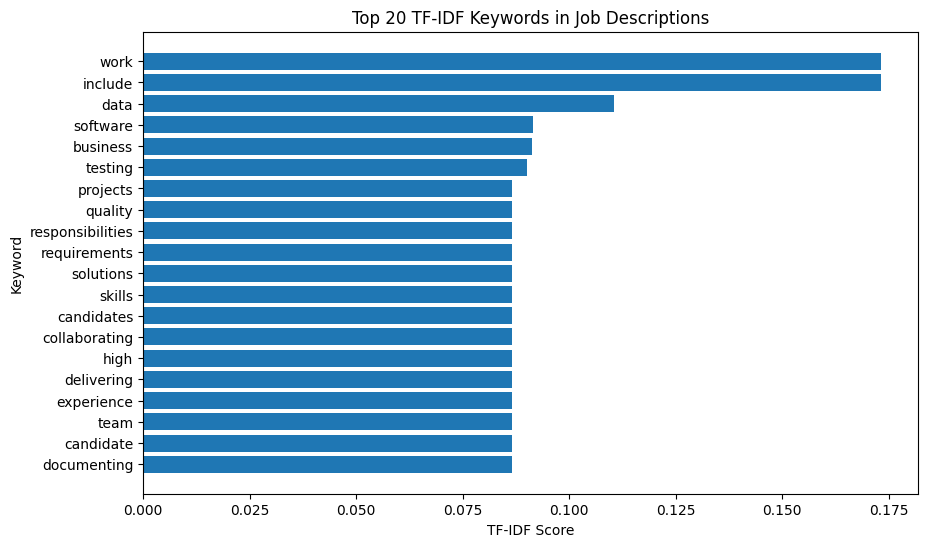

In [ ]:
top_20 = top_keywords.head(20).sort_values("TF-IDF Score")

plt.figure(figsize=(10, 6))

plt.barh(top_20["Term"], top_20["TF-IDF Score"])

plt.xlabel("TF-IDF Score")
plt.ylabel("Keyword")
plt.title("Top 20 TF-IDF Keywords in Job Descriptions")

plt.show()

In [ ]:
top_keywords.to_csv("TFIDF_keywords.csv", index=False)

print("TF-IDF Analysis Completed Successfully!")

TF-IDF Analysis Completed Successfully!
